In [1]:
!pip install gymnasium[box2d]
import gymnasium as gym
import numpy as np
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 51.5 MB/s eta 0:00:00


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)

### Реализация Multi-step DQN

In [3]:
class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self,
             state: np.ndarray,
             action: int,
             reward: float,
             next_state: np.ndarray,
             done: bool) -> None:
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards, dtype=np.float32),
                np.array(next_states), np.array(dones, dtype=np.float32))

    def __len__(self) -> int:
        return len(self.buffer)


class MultiStepReplayBuffer(ReplayBuffer):
    def __init__(self, capacity, n_step, gamma):
        super().__init__(capacity)
        self.n_step = n_step
        self.gamma = gamma
        self.n_step_buffer = deque(maxlen=n_step)

    def push(self, state, action, reward, next_state, done):
        # Накапливаем переходы
        self.n_step_buffer.append((state, action, reward, next_state, done))

        # Когда накопили n шагов
        if len(self.n_step_buffer) == self.n_step:
            state, action = self.n_step_buffer[0][0], self.n_step_buffer[0][1]

            # Суммируем награды с дисконтом
            reward_sum = 0
            next_state = None
            for i, (_, _, r, ns, d) in enumerate(self.n_step_buffer):
                reward_sum += (self.gamma ** i) * r
                next_state = ns  # последнее состояние
                if d:  # если эпизод закончился раньше, обрываем
                    break

            done = self.n_step_buffer[-1][4]  # флаг done последнего шага

            # Сохраняем в буфер как один переход
            super().push(state, action, reward_sum, next_state, done)

    def reset_n_step_buffer(self):
        self.n_step_buffer.clear()

In [4]:
class QNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_sizes: list):
        super().__init__()
        layers = []
        prev = state_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, action_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [5]:
class DQNAgent:
    def __init__(self, state_dim: int, action_dim: int, config: dict):
        self.action_dim = action_dim
        self.lr = config['lr']
        self.gamma = config['gamma']
        self.epsilon = config['epsilon_start']
        self.epsilon_min = config['epsilon_min']
        self.epsilon_decay = config['epsilon_decay']
        self.batch_size = config['batch_size']
        self.target_update_freq = config['target_update_freq']
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.q_net = QNetwork(state_dim, action_dim, hidden_sizes=config['hidden_sizes']).to(self.device)
        self.target_net = QNetwork(state_dim, action_dim, hidden_sizes=config['hidden_sizes']).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=self.lr)

        self.steps = 0

    def act(self, state: np.ndarray, explore: bool = True) -> int:
        if explore and np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)

        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.q_net(state_t)
        return q_values.argmax().item()

    def update(self, replay_buffer) -> float | None:
        if len(replay_buffer) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = replay_buffer.sample(self.batch_size)

        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)

        # Current Q values
        q_values = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Target Q values
        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(1)[0]
            target_q = rewards + self.gamma * next_q_values * (1 - dones)

        loss = nn.MSELoss()(q_values, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Update target network
        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return loss.item()

In [6]:
def apply_reward_shaping(state, next_state, reward, done, config):
    """Применяет reward shaping по формуле r' = r + gamma * phi(next) - phi(state)"""
    if not config.get('reward_shaping', False):
        return reward

    gamma = config.get('gamma', 0.99)
    phi = config.get('shaping_potential', None)

    if phi is None:
        return reward

    # phi_next = 0 для терминальных состояний
    phi_next = 0.0 if done else phi(next_state)
    phi_state = phi(state)

    return reward + gamma * phi_next - phi_state

def moving_average(data, window):
    return pd.Series(data).rolling(window, min_periods=1).mean().tolist()

def train_dqn(env, agent, replay_buffer, config,
              num_episodes: int,
              max_steps: int = 500,
              verbose: bool = True,
              smoothing_window: int = 20):
    episode_rewards = []
    episode_lengths = []
    losses = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        replay_buffer.reset_n_step_buffer()
        total_reward = 0
        ep_losses = []
        for step in range(max_steps):
            action = agent.act(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            shaped_reward = reward
            if config.get('reward_shaping', False):
                shaped_reward = apply_reward_shaping(state, next_state, reward, done, config)
            replay_buffer.push(state, action, shaped_reward, next_state, done)

            state = next_state
            total_reward += reward

            loss = agent.update(replay_buffer)
            if loss is not None:
                ep_losses.append(loss)

            if done:
                break

        episode_rewards.append(total_reward)
        episode_lengths.append(step+1)
        if ep_losses:
            losses.append(np.mean(ep_losses))

        if agent.epsilon > agent.epsilon_min:
            agent.epsilon *= agent.epsilon_decay

        if verbose:
            avg_reward = np.mean(episode_rewards[-smoothing_window:]) if len(episode_rewards) >= smoothing_window else np.mean(episode_rewards)
            avg_loss = np.mean(losses[-smoothing_window:]) if len(losses) >= smoothing_window and losses else np.mean(losses) if losses else 0.0
            print(f"Episode {episode+1:4d} | "
                  f"Reward: {total_reward:6.2f} | "
                  f"Avg Reward (last {smoothing_window}): {avg_reward:6.2f} | "
                  f"Length: {step+1:3d} | "
                  f"Epsilon: {agent.epsilon:.4f} | "
                  f"Loss: {np.mean(ep_losses) if ep_losses else 0.0:.6f} | "
                  f"Buffer: {len(replay_buffer)}")

    return {
        "rewards": episode_rewards,
        "lengths": episode_lengths,
        "losses": losses,
        "ma": moving_average(episode_rewards, smoothing_window),
        "mean_last": float(np.mean(episode_rewards[-smoothing_window:])),
        "best_reward": float(np.max(episode_rewards))
    }

### Эксперименты

In [7]:
def run_dqn_experiment(env, config, num_episodes=200, verbose=True, smoothing_window=20):
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = DQNAgent(state_dim, action_dim, config)
    buffer = MultiStepReplayBuffer(capacity=config.get('buffer_capacity', 10000),
                                   n_step=config.get('n_step', 3),
                                   gamma=config.get('gamma', 0.99))

    max_steps = config.get('max_steps', 500)

    results = train_dqn(env, agent, buffer, config, num_episodes, max_steps=max_steps,
                        verbose=verbose, smoothing_window=smoothing_window)
    return results

def plot_comparison(experiments_results, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Скользящее среднее наград
    for label, results in experiments_results:
        axes[0].plot(results["ma"], label=label, linewidth=2)
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Average Reward (MA)")
    axes[0].set_title("Smoothed Reward Curves")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    for label, results in experiments_results:
        axes[1].plot(results["losses"], label=label, linewidth=2, alpha=0.8)
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("Training Loss Curves")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

In [8]:
def make_base_config():
    return {
        'lr': 1e-3,
        'gamma': 0.99,
        'epsilon_start': 1.0,
        'epsilon_min': 0.01,
        'epsilon_decay': 0.99,
        'batch_size': 128,
        'target_update_freq': 100,
        'hidden_sizes': [128, 128],
        'buffer_capacity': 50000,
        'max_steps': 1000,
        'n_step': 3
    }

def baseline_experiment(env_name, config=None):
    if config is None:
        config = make_base_config()
    env = gym.make(env_name)

    results = run_dqn_experiment(env, config, num_episodes=300, verbose=True)
    plot_comparison([("Baseline Multi-step DQN", results)], title=f"Baseline Multi-step DQN on {env_name}")

    print(f"\nИтоговые метрики:")
    print(f"  Лучшая награда: {results['best_reward']:.0f}")
    print(f"  Средняя MA за последние 50: {results['mean_last']:.2f}")

#### Базовые запуски

Episode    1 | Reward: -200.00 | Avg Reward (last 20): -200.00 | Length: 200 | Epsilon: 0.9900 | Loss: 2.418702 | Buffer: 198
Episode    2 | Reward: -200.00 | Avg Reward (last 20): -200.00 | Length: 200 | Epsilon: 0.9801 | Loss: 0.822795 | Buffer: 396
Episode    3 | Reward: -200.00 | Avg Reward (last 20): -200.00 | Length: 200 | Epsilon: 0.9703 | Loss: 0.946137 | Buffer: 594
Episode    4 | Reward: -200.00 | Avg Reward (last 20): -200.00 | Length: 200 | Epsilon: 0.9606 | Loss: 1.314089 | Buffer: 792
Episode    5 | Reward: -200.00 | Avg Reward (last 20): -200.00 | Length: 200 | Epsilon: 0.9510 | Loss: 1.891446 | Buffer: 990
Episode    6 | Reward: -200.00 | Avg Reward (last 20): -200.00 | Length: 200 | Epsilon: 0.9415 | Loss: 3.044617 | Buffer: 1188
Episode    7 | Reward: -200.00 | Avg Reward (last 20): -200.00 | Length: 200 | Epsilon: 0.9321 | Loss: 4.099993 | Buffer: 1386
Episode    8 | Reward: -200.00 | Avg Reward (last 20): -200.00 | Length: 200 | Epsilon: 0.9227 | Loss: 5.702103 | Bu

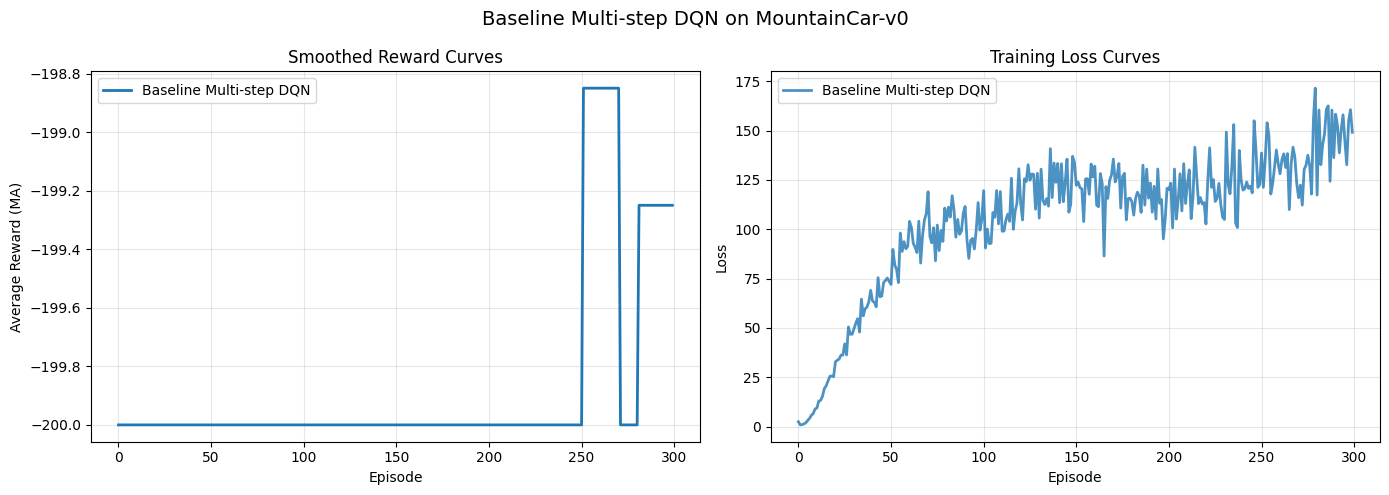


Итоговые метрики:
  Лучшая награда: -177
  Средняя MA за последние 50: -199.25


In [9]:
config = make_base_config()
config['reward_shaping'] = True
config['shaping_potential'] = lambda s: 300 * abs(s[1])
# config['shaping_potential'] = lambda s: 10 * (s[0] + 1.2) / 1.8
baseline_experiment("MountainCar-v0", config)

Episode    1 | Reward: -131.66 | Avg Reward (last 20): -131.66 | Length:  81 | Epsilon: 0.9900 | Loss: 0.000000 | Buffer: 79
Episode    2 | Reward: -231.54 | Avg Reward (last 20): -181.60 | Length:  83 | Epsilon: 0.9801 | Loss: 52.165015 | Buffer: 160
Episode    3 | Reward: -214.15 | Avg Reward (last 20): -192.45 | Length: 106 | Epsilon: 0.9703 | Loss: 80.949306 | Buffer: 264
Episode    4 | Reward: -297.58 | Avg Reward (last 20): -218.73 | Length:  91 | Epsilon: 0.9606 | Loss: 179.509819 | Buffer: 353
Episode    5 | Reward: -186.56 | Avg Reward (last 20): -212.30 | Length: 111 | Epsilon: 0.9510 | Loss: 94.999485 | Buffer: 462
Episode    6 | Reward: -71.06 | Avg Reward (last 20): -188.76 | Length:  71 | Epsilon: 0.9415 | Loss: 74.069585 | Buffer: 531
Episode    7 | Reward: -200.57 | Avg Reward (last 20): -190.45 | Length: 105 | Epsilon: 0.9321 | Loss: 114.827931 | Buffer: 634
Episode    8 | Reward: -162.91 | Avg Reward (last 20): -187.00 | Length:  79 | Epsilon: 0.9227 | Loss: 147.01044

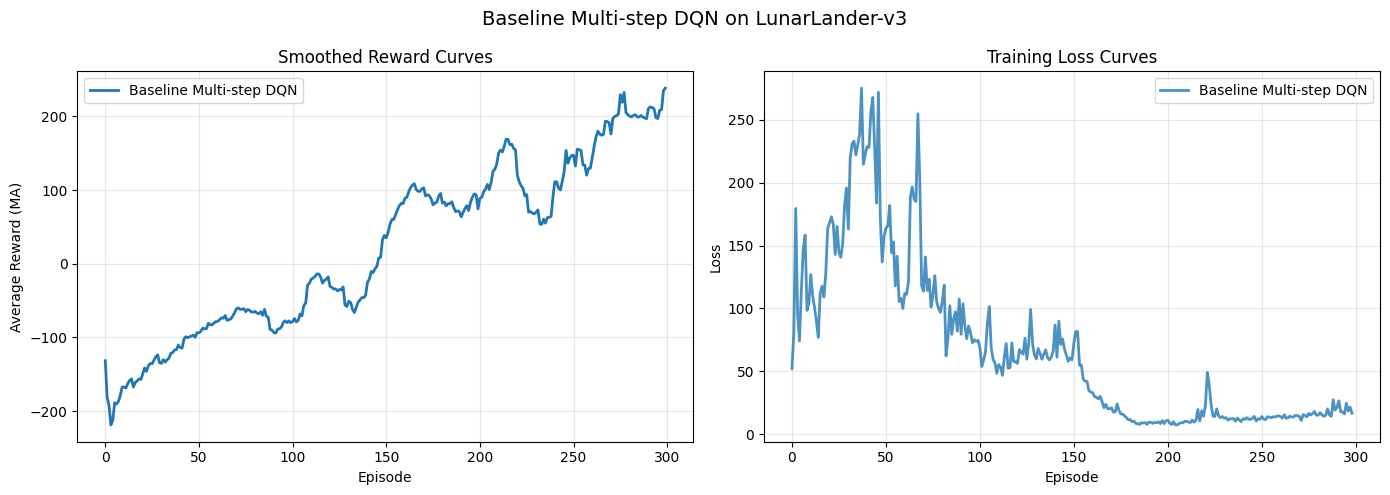


Итоговые метрики:
  Лучшая награда: 311
  Средняя MA за последние 50: 238.21


In [10]:
baseline_experiment("LunarLander-v3")

#### Эксперименты с варьированием параметров

In [11]:
def hyperparameter_experiment(env_name, param_name, param_values, base_config, num_episodes=200):
    env = gym.make(env_name)
    experiments_results = []

    for value in param_values:
        config = base_config.copy()
        config[param_name] = value

        label = f"{param_name}={value}"
        print(f"\nЗапуск: {label}")

        results = run_dqn_experiment(env, config, num_episodes=num_episodes, verbose=False)
        experiments_results.append((label, results))

        print(f"  Best reward: {results['best_reward']:.0f}, MA: {results['mean_last']:.2f}, Max loss: {max(results['losses']):.2f}")

    plot_comparison(experiments_results, title=f"Multi-step DQN в '{env_name}': Влияние параметра '{param_name}'")


ЭКСПЕРИМЕНТЫ ДЛЯ LunarLander-v3

Запуск: lr=0.0001
  Best reward: 229, MA: 138.39, Max loss: 2607.05

Запуск: lr=0.0005
  Best reward: 299, MA: 261.45, Max loss: 303.49

Запуск: lr=0.001
  Best reward: 297, MA: 146.28, Max loss: 4824.42

Запуск: lr=0.002
  Best reward: 297, MA: 179.61, Max loss: 479.50


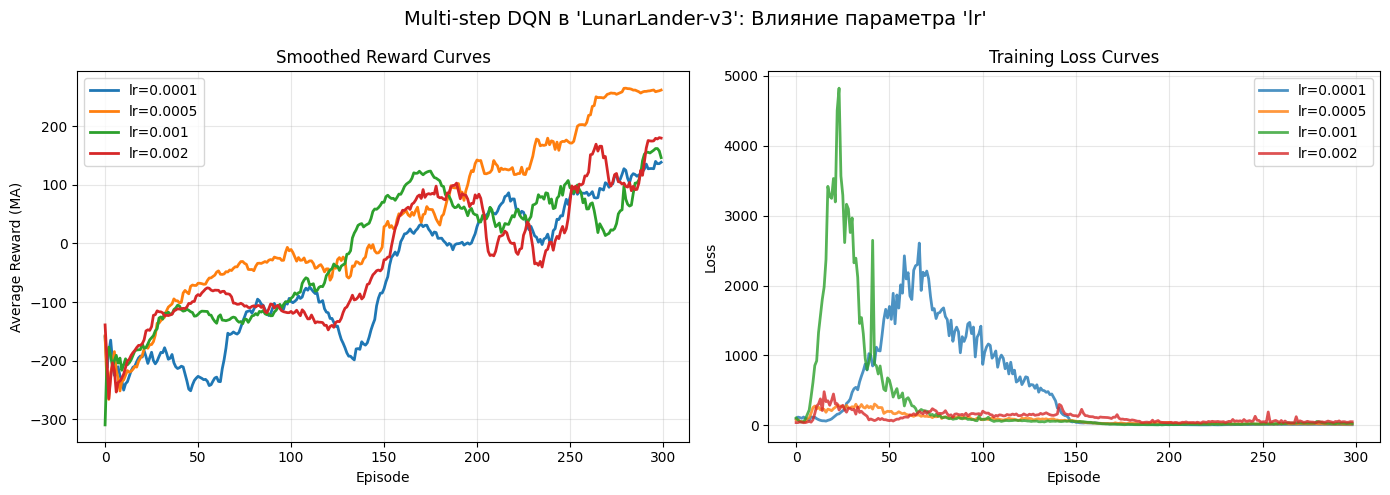


Запуск: gamma=0.9
  Best reward: 273, MA: -41.41, Max loss: 527.38

Запуск: gamma=0.95
  Best reward: 302, MA: 231.97, Max loss: 443.31

Запуск: gamma=0.99
  Best reward: 282, MA: 159.07, Max loss: 170.91

Запуск: gamma=0.995
  Best reward: 290, MA: -107.81, Max loss: 311.50


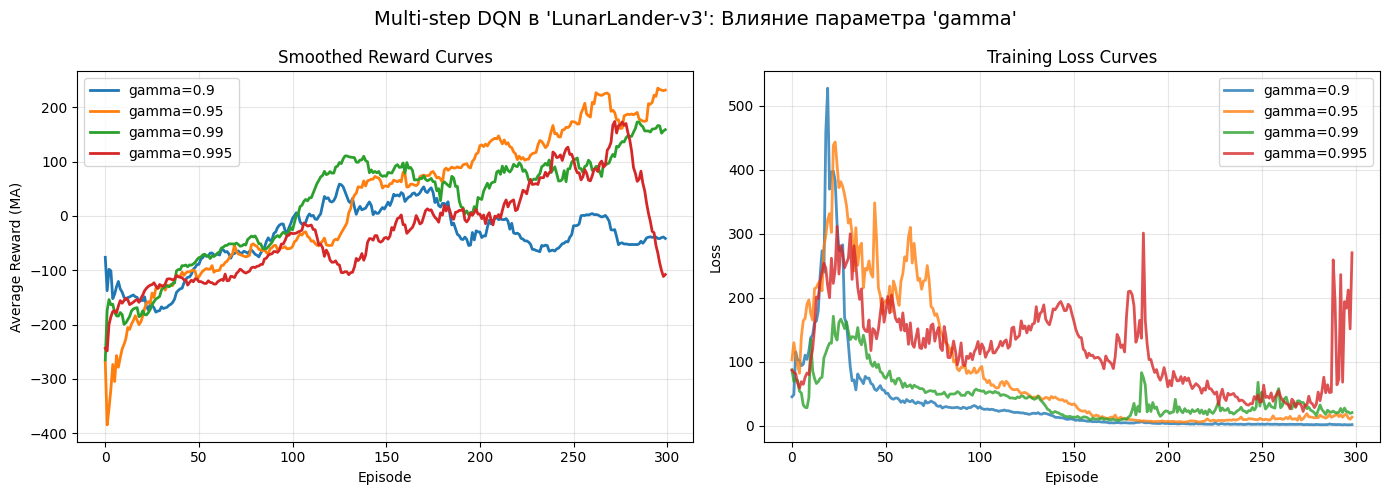


Запуск: batch_size=32
  Best reward: 311, MA: 218.86, Max loss: 784.06

Запуск: batch_size=64
  Best reward: 282, MA: 193.91, Max loss: 266.71

Запуск: batch_size=128
  Best reward: 281, MA: 45.31, Max loss: 648.30

Запуск: batch_size=256
  Best reward: 304, MA: 202.77, Max loss: 596.54


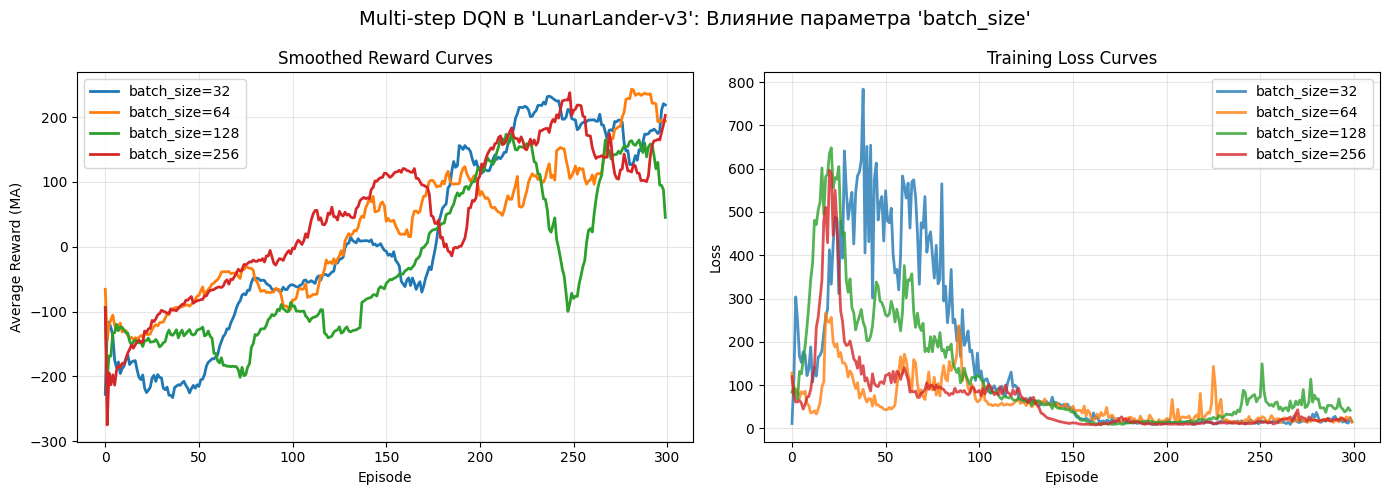


Запуск: target_update_freq=50
  Best reward: 305, MA: 204.15, Max loss: 591.65

Запуск: target_update_freq=100
  Best reward: 292, MA: 162.65, Max loss: 437.84

Запуск: target_update_freq=200
  Best reward: 311, MA: 259.82, Max loss: 119.13

Запуск: target_update_freq=500
  Best reward: 229, MA: 69.88, Max loss: 592.10


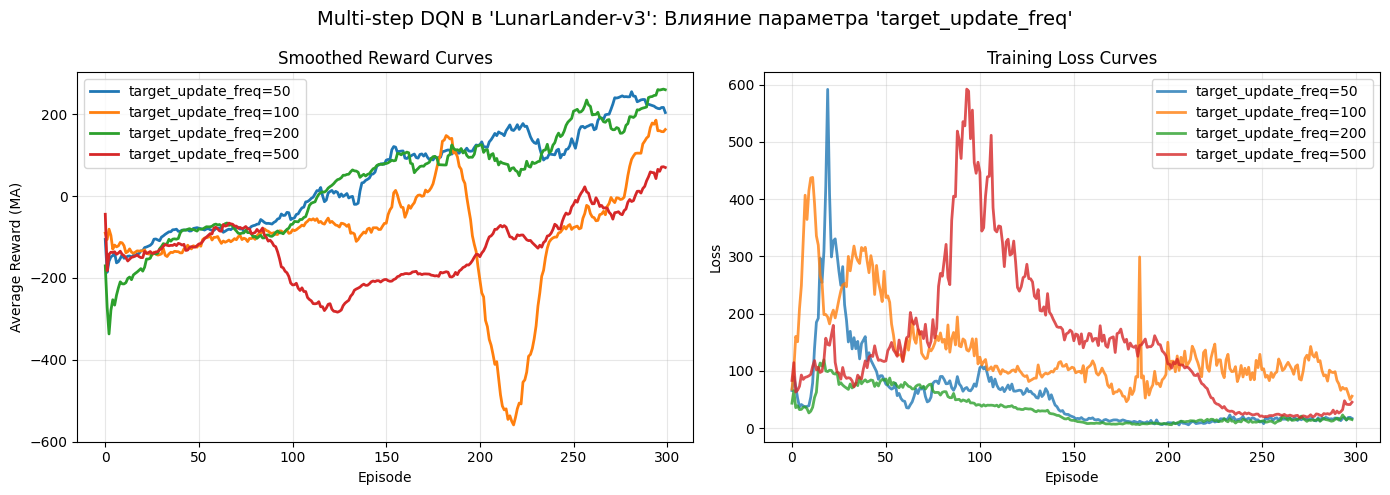


Запуск: n_step=1
  Best reward: 294, MA: 189.65, Max loss: 214.03

Запуск: n_step=3
  Best reward: 274, MA: 80.18, Max loss: 134.26

Запуск: n_step=5
  Best reward: 34, MA: -314.24, Max loss: 9195.01

Запуск: n_step=10
  Best reward: 30, MA: -958.11, Max loss: 42657254200.89


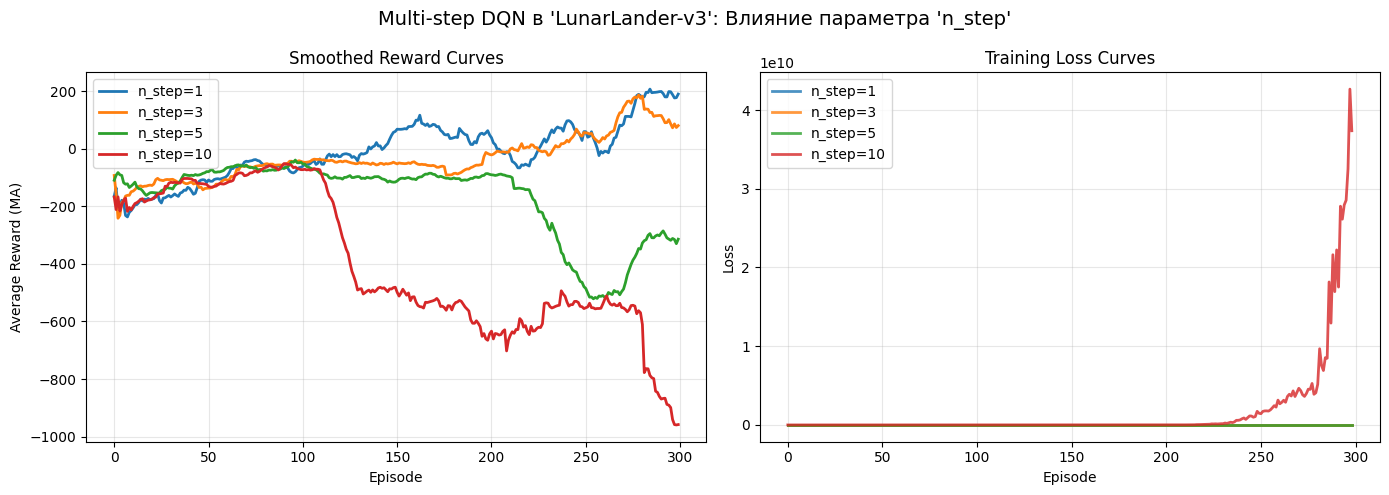


Запуск: epsilon_decay=0.9
  Best reward: 306, MA: 143.40, Max loss: 335.84

Запуск: epsilon_decay=0.95
  Best reward: 290, MA: 84.77, Max loss: 512.27

Запуск: epsilon_decay=0.99
  Best reward: 295, MA: 155.88, Max loss: 236.64

Запуск: epsilon_decay=0.995
  Best reward: 281, MA: 54.33, Max loss: 1880.33


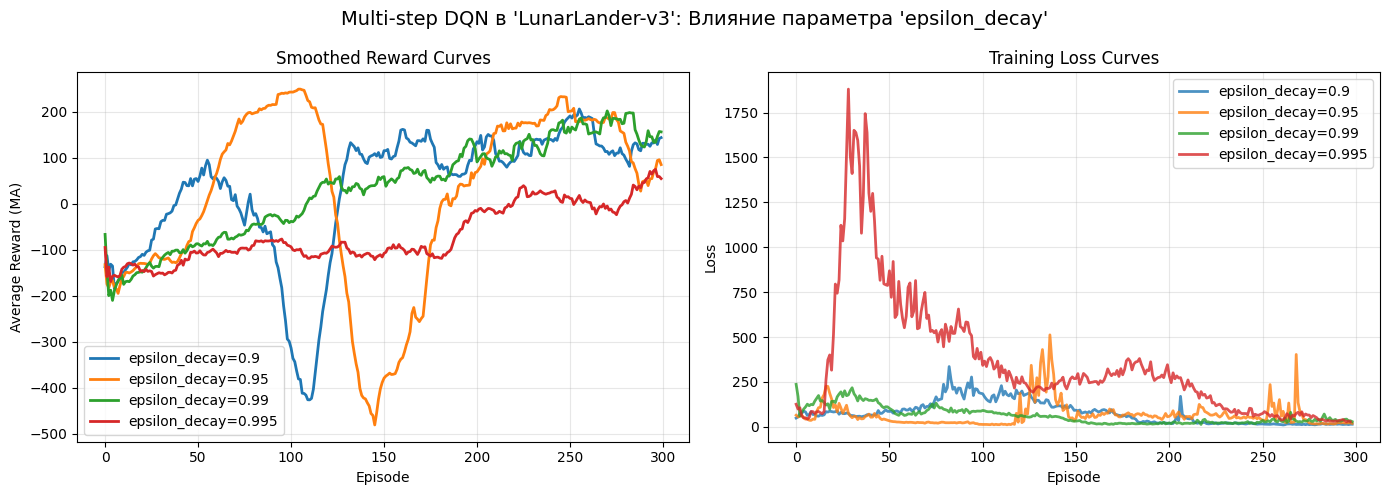


Запуск: hidden_sizes=[128]
  Best reward: 279, MA: 182.90, Max loss: 892.32

Запуск: hidden_sizes=[64, 64]
  Best reward: 297, MA: -920.43, Max loss: 4612.77

Запуск: hidden_sizes=[128, 128]
  Best reward: 253, MA: -259.67, Max loss: 4991.30

Запуск: hidden_sizes=[256]
  Best reward: 260, MA: 140.31, Max loss: 399.30

Запуск: hidden_sizes=[256, 256]
  Best reward: 292, MA: 105.92, Max loss: 9390.03


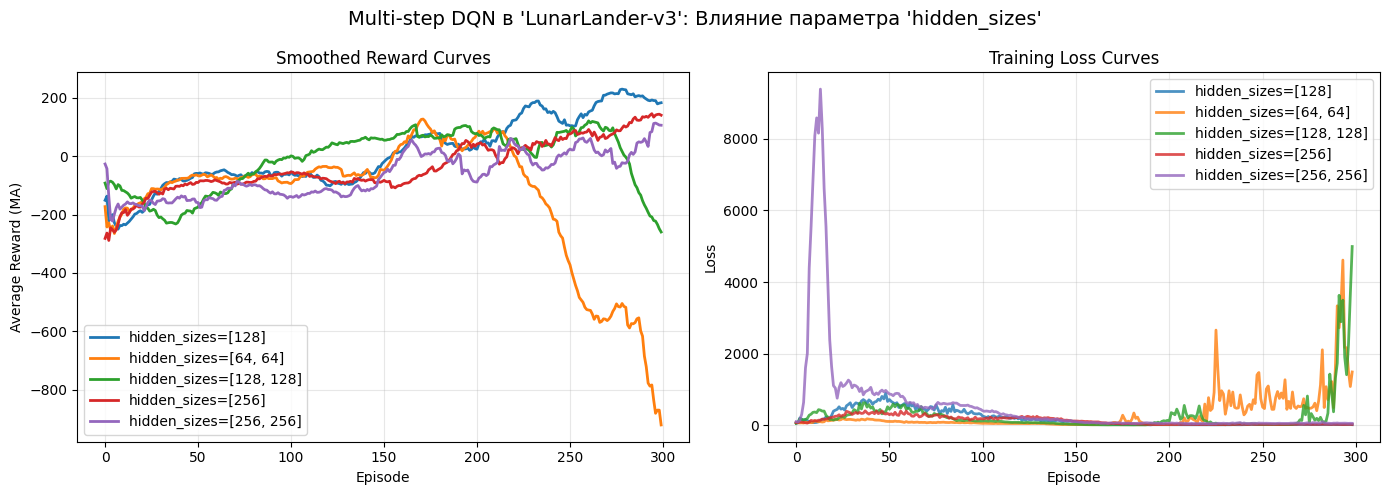


ЭКСПЕРИМЕНТЫ ДЛЯ MountainCar-v0

Запуск: lr=0.0001
  Best reward: -199, MA: -199.95, Max loss: 190.81

Запуск: lr=0.0005


In [ ]:
envs = ["LunarLander-v3", "MountainCar-v0"]

for env_name in envs:
    print(f"\n{'='*60}")
    print(f"ЭКСПЕРИМЕНТЫ ДЛЯ {env_name}")
    print(f"{'='*60}")
    base_config = make_base_config()

    if env_name == "MountainCar-v0":
      base_config['reward_shaping'] = True
      base_config['shaping_potential'] = lambda s: 300 * abs(s[1])
    else:
      base_config['reward_shaping'] = False

    hyperparameter_experiment(env_name, 'lr', [1e-4, 5e-4, 1e-3, 2e-3], base_config, num_episodes=300)

    hyperparameter_experiment(env_name, 'gamma', [0.9, 0.95, 0.99, 0.995], base_config, num_episodes=300)

    hyperparameter_experiment(env_name, 'batch_size', [32, 64, 128, 256], base_config, num_episodes=300)

    hyperparameter_experiment(env_name, 'target_update_freq', [50, 100, 200, 500], base_config, num_episodes=300)

    hyperparameter_experiment(env_name, 'n_step', [1, 3, 5, 10], base_config, num_episodes=300)

    hyperparameter_experiment(env_name, 'epsilon_decay', [0.9, 0.95, 0.99, 0.995], base_config, num_episodes=300)

    hyperparameter_experiment(env_name, 'hidden_sizes', [[128], [64,64], [128,128], [256], [256,256]], base_config, num_episodes=300)